# **Sobre os dados**

Este conjunto de dados é sobre a evasão de clientes de uma empresa de telefonia. Abaixo temos o dicionário de dados.

state - Código de 2 letras do estado americado de residencia do cliente

account length - numero de meses que o cliente está com o provedor de telecomunicações

area code - codigo de área

international plan - Se cliente possui plano internacional sim ou não

voice mail plan - Se o cliente tem plano de correio de voz sim ou não

number vmail messages - Numero de mensagem de correio de voz

total day minutes - total de minutos das chamadas diarias

total day calls - numeros total de chamadas diarias

total day charge - cobrança total das chamadas por dia

total eve minutes - total de minutos de chamadas noturnas

total eve calls - total de chamadas noturnas

total eve charge - cobrança total das chamadas noturna

total night minutes - total de minutos de chamadas noturnas

total night calls - Numero total de chamadas noturnas

total night charge - cobrança total das chamadas noturnas

total intl minutes - total de minutos para chamadas
internacionais

total intl calls - total de chamadas internacionais

total intl charge - cobrança total de chamadas internacionais

number customer service calls - numero de ligações para atendimento ao cliente

Churn - Evasão de clientes, sim ou não


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from xgboost import XGBClassifier
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, recall_score, f1_score, precision_score
from sklearn.model_selection import RandomizedSearchCV
import seaborn as sns
import warnings

In [ ]:
df = pd.read_csv('churn_train.csv')
df.shape

(4250, 20)

In [ ]:
df.sample(3)

,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,churn
917,RI,93,area_code_415,no,no,0,98.4,78,16.73,249.6,129,21.22,248.2,114,11.17,14.2,4,3.83,1,no
229,SD,144,area_code_408,no,yes,48,189.8,96,32.27,123.4,67,10.49,214.2,106,9.64,6.5,2,1.76,2,yes
1511,NY,54,area_code_415,no,no,0,286.6,73,48.72,223.2,108,18.97,203.7,107,9.17,11.5,5,3.11,1,yes


#### **Análise Exploratória**

In [ ]:
#
df.churn.value_counts()

,count
churn,
no,3652
yes,598


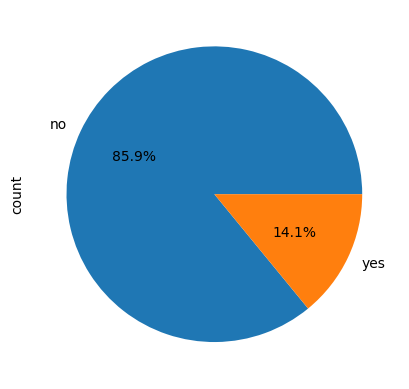

In [ ]:
#
df.churn.value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.show()

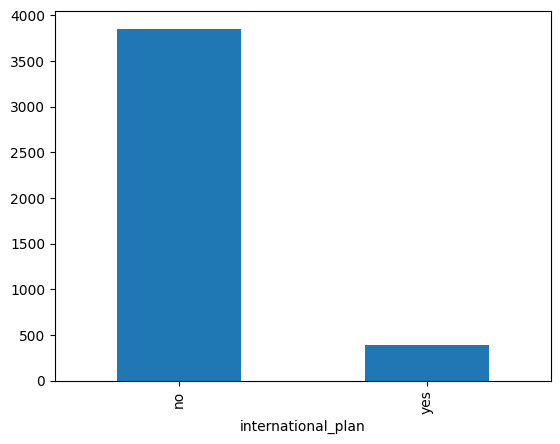

In [ ]:
#
df.international_plan.value_counts().plot(kind='bar')
plt.show()

In [ ]:
# Compilado de gráficos para análise
#sns.pairplot(df)

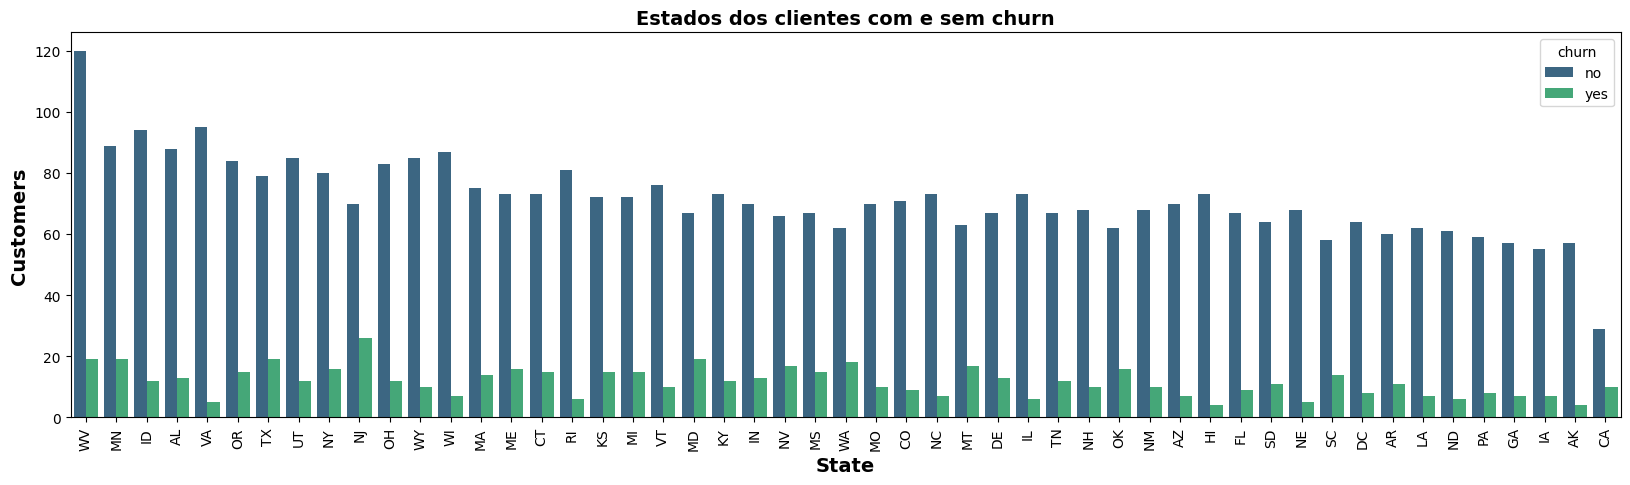

In [ ]:
fig, ax = plt.subplots(figsize=(20,5))

sns.countplot(data=df, x='state', order=df.state.value_counts().index, palette='viridis', hue='churn')

plt.xticks(rotation=90)
plt.xlabel('State',fontsize=14,fontweight='bold')
plt.ylabel('Customers', fontsize=14, fontweight='bold')
plt.title('Estados dos clientes com e sem churn', fontsize=14, fontweight='bold')
plt.show()

<Axes: >

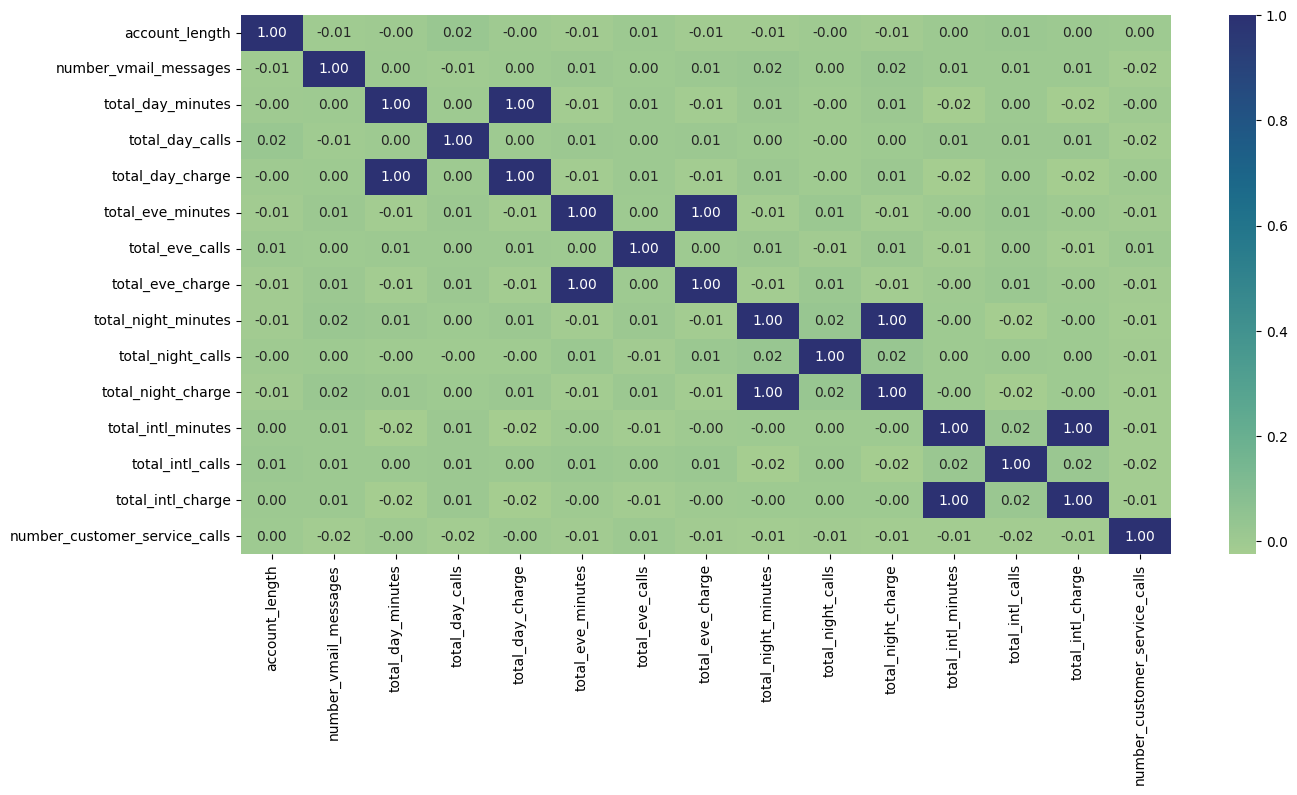

In [ ]:
df_corr = df.select_dtypes(exclude=["object"])
corr = df_corr.corr()
fig, ax = plt.subplots(figsize=(15,7))
sns.heatmap(corr,
            xticklabels=corr.columns.values,
            yticklabels=corr.columns.values,
            annot=True, cmap='crest',annot_kws={'size':10}, fmt='.2f')

#### Abordagem 1

**Feature Engineering**

In [ ]:
# Lista as variáveis do tipo objeto para transformação
objlist = df.select_dtypes(include='object').columns

In [ ]:
df2 = df.copy()

In [ ]:
for i in objlist:
  df[i] = df[i].astype('category')
  df[i] = df[i].cat.codes

In [ ]:
df.sample(4)

,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,churn
2322,45,21,1,0,0,0,223.2,142,37.94,216.5,114,18.40,214.7,111,9.66,12.4,2,3.35,1,0
3742,24,103,1,0,1,34,240.6,92,40.90,204.2,99,17.36,297.0,82,13.37,12.7,9,3.43,5,0
668,3,100,1,0,1,26,153.7,115,26.13,137.8,146,11.71,213.5,104,9.61,15.9,5,4.29,1,0
3006,48,72,1,0,0,0,129.8,106,22.07,188.7,138,16.04,212.5,116,9.56,8.3,4,2.24,4,1


In [ ]:
df.churn.value_counts()

,count
churn,
0,3652
1,598


In [ ]:
# Divisão de variáveis dependente e independentes

X = df.drop('churn', axis=1) # df.drop apaga uma variável, axis=1 indica que é uma coluna a ser dropada, axis=0 indica que é linha
y = df['churn']

In [ ]:
# Divisão de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=987)

In [ ]:
# Bibliotecas para o modelo
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn import tree
from sklearn.tree import export_text
from sklearn.tree import plot_tree
import plotly.graph_objects as go
import plotly.express as px

In [ ]:
# Arvore de decisão simples
clf = DecisionTreeClassifier(random_state=1234)

In [ ]:
# Treinamento do modelo
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1234)

In [ ]:
features = X_train.columns
tree_text = export_text(clf, feature_names=features)
print("Representação textual da árvore de decisão:")
print(tree_text) # Retorna a montagem da arvore de decisão, caso queira mandar para um sistema externo

Representação textual da árvore de decisão:
|--- total_day_minutes <= 264.45
|   |--- number_customer_service_calls <= 3.50
|   |   |--- international_plan <= 0.50
|   |   |   |--- total_day_charge <= 37.72
|   |   |   |   |--- account_length <= 224.50
|   |   |   |   |   |--- total_eve_minutes <= 325.95
|   |   |   |   |   |   |--- number_vmail_messages <= 47.50
|   |   |   |   |   |   |   |--- total_night_charge <= 10.78
|   |   |   |   |   |   |   |   |--- total_day_calls <= 120.50
|   |   |   |   |   |   |   |   |   |--- state <= 49.50
|   |   |   |   |   |   |   |   |   |   |--- total_night_calls <= 61.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 4
|   |   |   |   |   |   |   |   |   |   |--- total_night_calls >  61.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 11
|   |   |   |   |   |   |   |   |   |--- state >  49.50
|   |   |   |   |   |   |   |   |   |   |--- total_eve_minutes <= 283.85
|   |   |   |   |   |   | 

In [ ]:
cols = list(df.columns) # Captura os nomes das colunas em uma lista
cols.remove('churn') # Remove apenas a coluna churn da lista

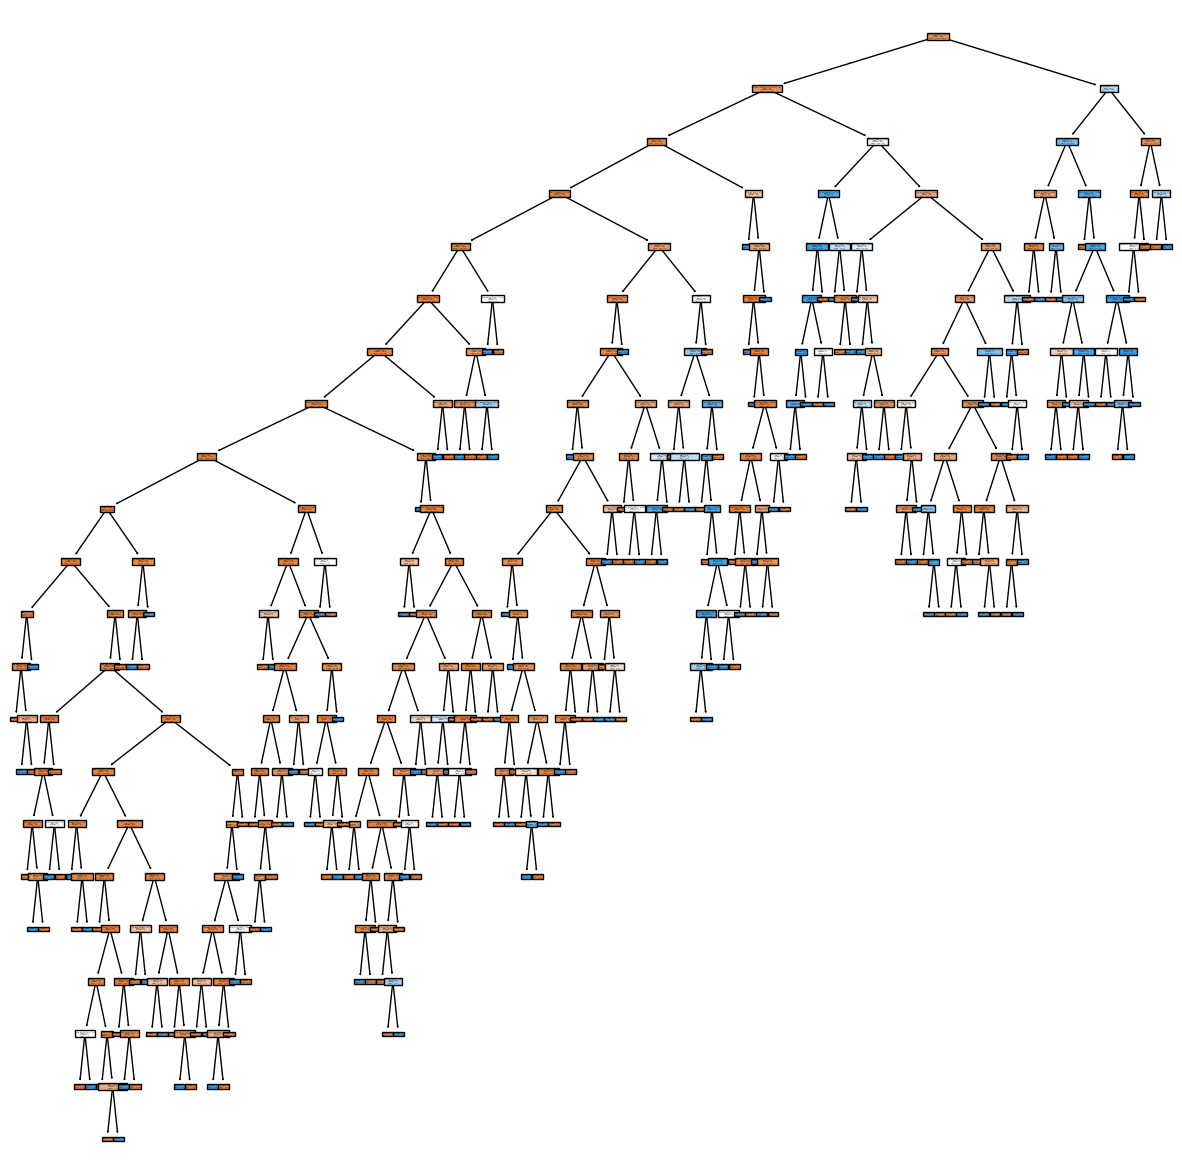

In [ ]:
# Melhorar a visualização do gráfico
fig = plt.figure(figsize=(15, 15))
p = tree.plot_tree(clf,
                   feature_names=cols,
                   filled=True)

In [ ]:
# Instanciamos os algoritmos todos com hiperparametros padrão
lr = LogisticRegression(solver='sag')
dt = DecisionTreeClassifier()
rn = RandomForestClassifier()
knn = KNeighborsClassifier()
gb = GaussianNB()
sgd = SGDClassifier()
xgb = XGBClassifier()

In [ ]:
models = [lr, dt, rn, knn, gb, sgd, xgb] # Lista com os algoritmos
d = {}  # Cria dicionário vazio

for i in models:
  i.fit(X_train, y_train) # Treina os modelos de acordo com a interação na lista
  ypred = i.predict(X_test) # Faz predição nos dados de teste do modelo treinado
  print(i, ":", accuracy_score(ypred, y_test)*100) # Apresenta na tela o algoritmo e a acurácia do modelo
  d.update({str(i):i.score(X_test, y_test)*100}) # Salva no dicionário "d" o resultado do modelo e o nome do modelo

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(solver='sag') : 84.58823529411764
DecisionTreeClassifier() : 92.3529411764706
RandomForestClassifier() : 96.0
KNeighborsClassifier() : 87.76470588235294
GaussianNB() : 85.52941176470588
SGDClassifier() : 84.70588235294117
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...

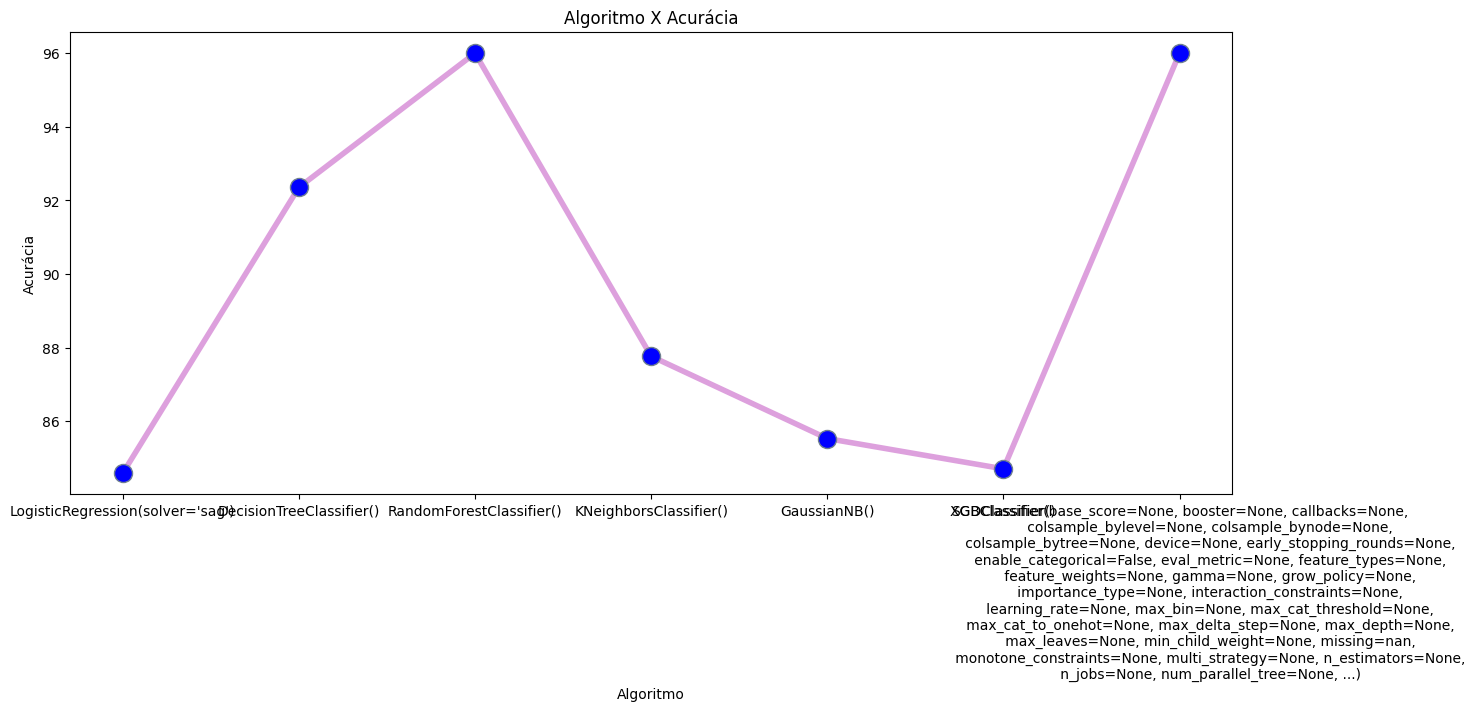

In [ ]:
plt.figure(figsize=(15,6))
plt.title('Algoritmo X Acurácia')
plt.xlabel('Algoritmo')
plt.ylabel('Acurácia')
plt.plot(d.keys(), d.values(), marker='o', color='plum', linewidth=4, markersize=13,
         markerfacecolor='blue', markeredgecolor='slategray')
plt.show()

#### Escolhendo um modelo

In [ ]:
rf_model = RandomForestClassifier(n_estimators=200,
                                  max_depth=4,
                                  n_jobs=10,
                                  min_samples_split=2,
                                  min_samples_leaf=2,
                                  max_features=None)

In [ ]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=4, max_features=None, min_samples_leaf=2,
                       n_estimators=200, n_jobs=10)

In [ ]:
ypred = rf_model.predict(X_test)

In [ ]:
accuracy_score(y_test, ypred)

0.9235294117647059

In [ ]:
recall_score(y_test, ypred)

0.5307692307692308

In [ ]:
f1_score(y_test, ypred)

0.6798029556650246

In [ ]:
precision_score(y_test,ypred)

0.9452054794520548

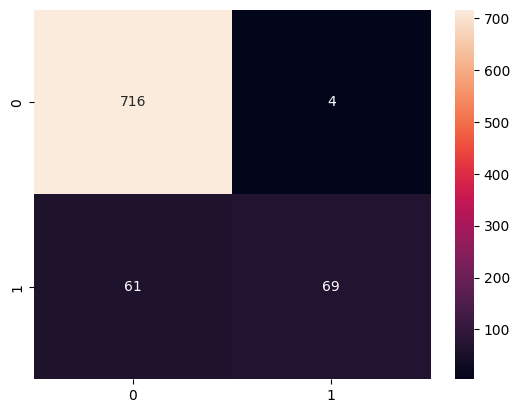

In [ ]:
cm = confusion_matrix(y_test, rf_model.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [ ]:
# Feature Importance
# Obter a importância das features
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values('Importance', ascending=False)

# Criar gráfico interativo com Plotly
fig = px.bar(feature_importance, x='Importance', y='Feature', orientation='h',
             title='Importância das Features no Random Forest Classifier',
             labels={'Importance': 'Importância', 'Feature': 'Variáveis'},
             height=600, width=800)

# Personalizar o layout
fig.update_traces(marker_color='rgb(158,202,225)', marker_line_color='rgb(8,48,107)',
                  marker_line_width=1.5, opacity=0.8)
fig.update_layout(
    title_x=0.5,
    xaxis_title="Importância",
    yaxis_title="Variáveis",
    showlegend=False
)

# Exibir o gráfico
fig.show()

#### Tuning de parametros

In [ ]:
n_estimators = [50, 100, 150, 200, 250, 300, 400] # Somente numeros inteiros
min_samples_split = [2, 3, 4, 8] # Somente numeros inteiros
min_samples_leaf = [1, 2, 4, 8] # Somente numeros inteiros
max_features = ['auto', 'sqrt', 'log2', None]
max_depth = [2, 4, 6, 8] # Somente numeros inteiros

params = {
    'n_estimators': n_estimators,
    'min_samples_split': min_samples_split,
    'min_samples_leaf': min_samples_leaf,
    'max_features': max_features,
    'max_depth': max_depth
}

In [ ]:
rf_tuned = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=37),
                              param_distributions=params, # Dicionário com os parametros
                              cv=5,  # Validação cruzada
                              n_iter=10, # Numero de interações
                              scoring='recall', # Métrica de assertividade que estamos buscando melhorar
                              n_jobs=-1, # Uso de processadores, abertura de threads -1 usa 100% do recurso
                              verbose=0) # Saida de Logs

In [ ]:
rf_tuned.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=37),
                   n_jobs=-1,
                   param_distributions={'max_depth': [2, 4, 6, 8],
                                        'max_features': ['auto', 'sqrt', 'log2',
                                                         None],
                                        'min_samples_leaf': [1, 2, 4, 8],
                                        'min_samples_split': [2, 3, 4, 8],
                                        'n_estimators': [50, 100, 150, 200, 250,
                                                         300, 400]},
                   scoring='recall')

In [ ]:
ypred = rf_tuned.predict(X_test)

In [ ]:
accuracy_score(y_test, ypred)

0.9576470588235294

In [ ]:
recall_score(y_test, ypred)

0.7384615384615385

In [ ]:
f1_score(y_test, ypred)

0.8421052631578947

In [ ]:
precision_score(y_test, ypred)

0.9795918367346939

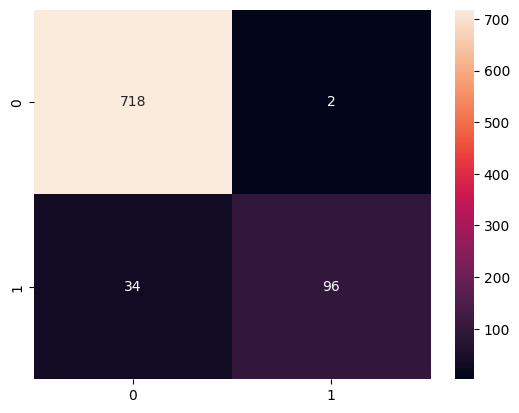

In [ ]:
cm = confusion_matrix(y_test, rf_tuned.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [ ]:
rf_tuned.best_params_

{'n_estimators': 200,
 'min_samples_split': 4,
 'min_samples_leaf': 1,
 'max_features': None,
 'max_depth': 8}

#### Salvando um modelo

In [ ]:
import joblib

In [ ]:
# Modelo salvo no diretorio
joblib.dump(rf_tuned, '/content/rf_tuned_74_recall.joblib')
joblib.dump(rf_tuned, '/content/rf_tuned_74_recall.pkl')

['/content/rf_tuned_74_recall.pkl']

In [ ]:
# Quando for usar o modelo faça um load
model = joblib.load('/content/rf_tuned_74_recall.joblib')

#### Feature Selection

In [ ]:
from sklearn.feature_selection import SelectKBest, chi2

In [ ]:
select_feature = SelectKBest(chi2, k=10).fit(X_train, y_train)

In [ ]:
a = select_feature.scores_
b = X_train.columns
df2 =pd.DataFrame(list(zip(b, a)), columns=['Column', 'Score'])

df2['Score'] = df2['Score'].replace(np.nan, 0)
df2['Score'] = df2['Score'].astype(int)
df2.sort_values(by='Score', ascending=False)

,Column,Score
6,total_day_minutes,2592
5,number_vmail_messages,823
8,total_day_charge,440
9,total_eve_minutes,248
3,international_plan,242
18,number_customer_service_calls,179
12,total_night_minutes,78
1,account_length,35
4,voice_mail_plan,34
11,total_eve_charge,21


## **Exercício de hoje**

1. Faça todas as etapas que fizemos nesta aula no dataset train.csv que é referente ao range de preços de um aparelho celular.

Segue o dicionário de dados do dataset:


* battery_power - Energia total que uma bateria pode armazenar de uma só vez, medida em mAh
* azul - Possui bluetooth ou não
* clock_speed - velocidade na qual o microprocessador executa instruções
* dual_sim - Possui suporte dual sim ou não
* fc - Mega pixels da câmera frontal
* four_g - Possui 4G ou não
* int_memory – Memória interna em Gigabytes
* m_dep - Profundidade móvel em cm
* mobile_wt - Peso do celular
* n_cores – Número de núcleos do processador
* pc - Mega pixels da câmera principal
* px_height - Altura da resolução de pixel
* px_width - Largura da resolução de pixel
* ram - Memória de acesso aleatório em Mega Bytes
* sc_h - Altura da tela do celular em cm
* sc_w - Largura da tela do celular em cm
* talk_time - maior tempo que uma única carga de bateria durará quando você estiver
* three_g - Tem 3G ou não
* touch_screen - Possui touch screen ou não
* wifi - Tem wifi ou não
* price_range - Esta é a variável alvo com valor 0 (custo baixo), 1 (custo médio), 2 (custo alto) e 3 (custo muito alto).